In [4]:
# Cell 1: Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Cell 2: Install gdown
!pip install gdown -q

import gdown

# Paste your friend's shared link here
shared_link = "https://drive.google.com/file/d/1IcMkNaEqTl5ycoRewEwQjDmRkV33Z9CX/view?usp=drive_link"

# Extract the file ID from the link
# Link looks like: .../file/d/FILE_ID_HERE/view...
file_id = shared_link.split('/d/')[1].split('/view')[0]
print("File ID:", file_id)

# Download the zip
gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "/content/mamia_dataset.zip",
    quiet=False
)
print("✅ Download complete!")

File ID: 1IcMkNaEqTl5ycoRewEwQjDmRkV33Z9CX


Downloading...
From (original): https://drive.google.com/uc?id=1IcMkNaEqTl5ycoRewEwQjDmRkV33Z9CX
From (redirected): https://drive.google.com/uc?id=1IcMkNaEqTl5ycoRewEwQjDmRkV33Z9CX&confirm=t&uuid=ed1515e5-8d0c-41cc-ae87-8706fc394d30
To: /content/mamia_dataset.zip
100%|██████████| 1.85G/1.85G [00:46<00:00, 39.8MB/s]

✅ Download complete!


In [6]:
# Cell 3: Unzip
import zipfile
import os

print("Unzipping... this may take a few minutes")

with zipfile.ZipFile("/content/mamia_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/mamia_dataset")

print("✅ Unzip complete!")
print("\nFiles extracted:")
print(os.listdir("/content/mamia_dataset"))

Unzipping... this may take a few minutes
✅ Unzip complete!

Files extracted:
['mamia_dataset']


In [7]:
# Cell 4: Check structure
import os

base_path = "/content/mamia_dataset"

# Walk through all folders
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = '│   ' * level + '├── '
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show files 2 levels deep
        for file in files[:3]:  # Show first 3 files only
            print(f"{'│   ' * (level+1)}├── {file}")

├── mamia_dataset/
│   ├── mamia_dataset/
│   │   ├── train_test_splits.csv
│   │   ├── preliminary_automatic_segmentations_quality_scores.csv
│   │   ├── clinical_and_imaging_info.xlsx
│   │   ├── segmentations/
│   │   │   ├── automatic/
│   │   │   │   ├── DUKE_009.nii/
│   │   │   │   ├── DUKE_002.nii/
│   │   │   │   ├── DUKE_010.nii/
│   │   │   │   ├── DUKE_005.nii/
│   │   │   │   ├── DUKE_001.nii/
│   │   │   ├── expert/
│   │   │   │   ├── DUKE_009.nii/
│   │   │   │   ├── DUKE_002.nii/
│   │   │   │   ├── DUKE_010.nii/
│   │   │   │   ├── DUKE_005.nii/
│   │   │   │   ├── DUKE_001.nii/
│   │   ├── patient_info_files/
│   │   ├── images/
│   │   │   ├── DUKE_010/
│   │   │   │   ├── DUKE_010_0000.nii/
│   │   │   │   ├── DUKE_010_0001.nii/
│   │   │   │   ├── DUKE_010_0002.nii/
│   │   │   │   ├── DUKE_010_0003.nii/
│   │   │   ├── DUKE_002/
│   │   │   │   ├── DUKE_002_0000.nii/
│   │   │   │   ├── DUKE_002_0002.nii/
│   │   │   │   ├── DUKE_002_0003.nii/
│   │   │   │   ├──

In [8]:
# Cell 5: Load clinical data (FIXED PATH)
import pandas as pd

# ✅ CORRECTED PATH
excel_path = "/content/mamia_dataset/mamia_dataset/clinical_and_imaging_info.xlsx"
df = pd.read_excel(excel_path)

print("✅ Clinical data loaded!")
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

✅ Clinical data loaded!

Shape: (5, 50)

Columns: ['patient_id', 'dataset', 'bilateral_breast_cancer', 'multifocal_cancer', 'nac_agent', 'endocrine_therapy', 'anti_her2_neu_therapy', 'pcr', 'mastectomy_post_nac', 'days_to_follow_up', 'days_to_recurrence', 'days_to_metastasis', 'days_to_death', 'hr', 'er', 'pr', 'her2', 'mammaprint', 'oncotype_score', 'nottingham_grade', 'tumor_subtype', 'age', 'menopause', 'ethnicity', 'has_implant', 'weight', 'patient_size', 'bmi_group', 'breast_density', 'view', 'bilateral_mri', 'num_phases', 'fat_suppressed', 'field_strength', 'image_rows', 'image_columns', 'num_slices', 'pixel_spacing', 'slice_thickness', 'site', 'manufacturer', 'scanner_model', 'high_bit', 'window_center', 'window_width', 'echo_time', 'repetition_time', 'acquisition_times', 'acquisition_date', 'tcia_series_uid']

First 3 rows:


,patient_id,dataset,bilateral_breast_cancer,multifocal_cancer,nac_agent,endocrine_therapy,anti_her2_neu_therapy,pcr,mastectomy_post_nac,days_to_follow_up,...,manufacturer,scanner_model,high_bit,window_center,window_width,echo_time,repetition_time,acquisition_times,acquisition_date,tcia_series_uid
0,DUKE_001,DUKE,0,0,NaN,0,1,0,0,2940,...,SIEMENS,Avanto,11,53,145,1.360,4.120,"[0, 584, 714, 846, 977]",NaN,1.3.6.1.4.1.14519.5.2.1.1857778498036652445367...
1,DUKE_002,DUKE,0,0,NaN,0,0,0,0,1649,...,GE,Signa HDxt,15,326,652,2.704,6.918,"[0, 165, 288, 411]",NaN,1.3.6.1.4.1.14519.5.2.1.2920879504444133146439...
2,DUKE_005,DUKE,0,1,NaN,0,1,1,1,1845,...,SIEMENS,Avanto,11,106,288,1.340,4.270,"[0, 183, 289, 398]",NaN,1.3.6.1.4.1.14519.5.2.1.3082672827908226352755...


In [9]:
# Cell: Master Paths
import os
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import torch

base_path  = "/content/mamia_dataset/mamia_dataset"
excel_path = f"{base_path}/clinical_and_imaging_info.xlsx"
splits_path = f"{base_path}/train_test_splits.csv"
seg_path   = f"{base_path}/segmentations"
images_path = f"{base_path}/images"
patient_info_path = f"{base_path}/patient_info_files"
full_seg_path = f"{base_path}/full_image_dce_mri_tumor_segmentation"

print("✅ Paths set!")
print("\nContents of base folder:")
for item in sorted(os.listdir(base_path)):
    print(f"  ├── {item}")

✅ Paths set!

Contents of base folder:
  ├── clinical_and_imaging_info.xlsx
  ├── full_image_dce_mri_tumor_segmentation
  ├── images
  ├── patient_info_files
  ├── preliminary_automatic_segmentations_quality_scores.csv
  ├── segmentations
  ├── train_test_splits.csv


In [10]:
# Cell 6: Load all data files
# Clinical data
df = pd.read_excel(excel_path)
print("✅ Clinical Excel loaded!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

# Train/test splits
splits_df = pd.read_csv(splits_path)
print("\n✅ Train/Test splits loaded!")
print(splits_df.head())
print("\nSplit counts:")
print(splits_df.value_counts())

# Segmentation quality scores
seg_quality_df = pd.read_csv(
    f"{base_path}/preliminary_automatic_segmentations_quality_scores.csv"
)
print("\n✅ Segmentation quality loaded!")
print(seg_quality_df.head())

✅ Clinical Excel loaded!
Shape: (5, 50)
Columns: ['patient_id', 'dataset', 'bilateral_breast_cancer', 'multifocal_cancer', 'nac_agent', 'endocrine_therapy', 'anti_her2_neu_therapy', 'pcr', 'mastectomy_post_nac', 'days_to_follow_up', 'days_to_recurrence', 'days_to_metastasis', 'days_to_death', 'hr', 'er', 'pr', 'her2', 'mammaprint', 'oncotype_score', 'nottingham_grade', 'tumor_subtype', 'age', 'menopause', 'ethnicity', 'has_implant', 'weight', 'patient_size', 'bmi_group', 'breast_density', 'view', 'bilateral_mri', 'num_phases', 'fat_suppressed', 'field_strength', 'image_rows', 'image_columns', 'num_slices', 'pixel_spacing', 'slice_thickness', 'site', 'manufacturer', 'scanner_model', 'high_bit', 'window_center', 'window_width', 'echo_time', 'repetition_time', 'acquisition_times', 'acquisition_date', 'tcia_series_uid']

First 3 rows:
  patient_id dataset  bilateral_breast_cancer  multifocal_cancer  nac_agent  \
0   DUKE_001    DUKE                        0                  0        NaN   

In [11]:
# Cell 7: Explore images
patients = sorted(os.listdir(images_path))
print(f"Total patients in images folder: {len(patients)}")
print("\nPatient IDs:")
for p in patients[:10]:  # Show first 10
    print(f"  ├── {p}")

# Look inside first patient folder
first_patient = patients[0]
patient_folder = os.path.join(images_path, first_patient)
print(f"\nFiles inside patient {first_patient}:")
for f in os.listdir(patient_folder):
    size = os.path.getsize(os.path.join(patient_folder, f))
    print(f"  ├── {f}  ({size/1024/1024:.1f} MB)")

Total patients in images folder: 5

Patient IDs:
  ├── DUKE_001
  ├── DUKE_002
  ├── DUKE_005
  ├── DUKE_009
  ├── DUKE_010

Files inside patient DUKE_001:
  ├── DUKE_001_0001.nii  (0.0 MB)
  ├── DUKE_001_0003.nii  (0.0 MB)
  ├── DUKE_001_0002.nii  (0.0 MB)
  ├── DUKE_001_0004.nii  (0.0 MB)
  ├── manifest.csv  (0.0 MB)
  ├── DUKE_001_0000.nii  (0.0 MB)


In [12]:
# Cell 8 FIXED: Handle nested folder structure
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

images_path = "/content/mamia_dataset/mamia_dataset/images"
patients = sorted(os.listdir(images_path))
first_patient = patients[0]
patient_folder = os.path.join(images_path, first_patient)

def find_nii_files(patient_folder):
    """Recursively find all .nii files inside patient folder"""
    nii_files = []
    for root, dirs, files in os.walk(patient_folder):
        for f in files:
            if f.endswith('.nii') or f.endswith('.nii.gz'):
                full_path = os.path.join(root, f)
                size = os.path.getsize(full_path) / 1024 / 1024
                nii_files.append((f, full_path, size))
    return sorted(nii_files)

# Find all real files
nii_files = find_nii_files(patient_folder)
print(f"Patient: {first_patient}")
print(f"\nAll NII files found:")
for name, path, size in nii_files:
    print(f"  ├── {name} → {size:.2f} MB")
    print(f"       Path: {path}")

# Load timepoint 0001 (post-contrast, best for tumor)
target_files = [(n, p, s) for n, p, s in nii_files if '0001' in n]
if target_files:
    _, mri_path, size = target_files[0]
else:
    _, mri_path, size = nii_files[0]

print(f"\nLoading: {mri_path} ({size:.2f} MB)")
mri = nib.load(mri_path)
mri_data = mri.get_fdata()
print(f"✅ Loaded! Shape: {mri_data.shape}")

Patient: DUKE_001

All NII files found:
  ├── DUKE_001_0000.nii → 61.25 MB
       Path: /content/mamia_dataset/mamia_dataset/images/DUKE_001/DUKE_001_0000.nii/DUKE_001_0000.nii
  ├── DUKE_001_0001.nii → 61.25 MB
       Path: /content/mamia_dataset/mamia_dataset/images/DUKE_001/DUKE_001_0001.nii/DUKE_001_0001.nii
  ├── DUKE_001_0002.nii → 61.25 MB
       Path: /content/mamia_dataset/mamia_dataset/images/DUKE_001/DUKE_001_0002.nii/DUKE_001_0002.nii
  ├── DUKE_001_0003.nii → 61.25 MB
       Path: /content/mamia_dataset/mamia_dataset/images/DUKE_001/DUKE_001_0003.nii/DUKE_001_0003.nii
  ├── DUKE_001_0004.nii → 61.25 MB
       Path: /content/mamia_dataset/mamia_dataset/images/DUKE_001/DUKE_001_0004.nii/DUKE_001_0004.nii

Loading: /content/mamia_dataset/mamia_dataset/images/DUKE_001/DUKE_001_0001.nii/DUKE_001_0001.nii (61.25 MB)
✅ Loaded! Shape: (448, 448, 160)


MRI shape: (448, 448, 160)
Middle slice: 80


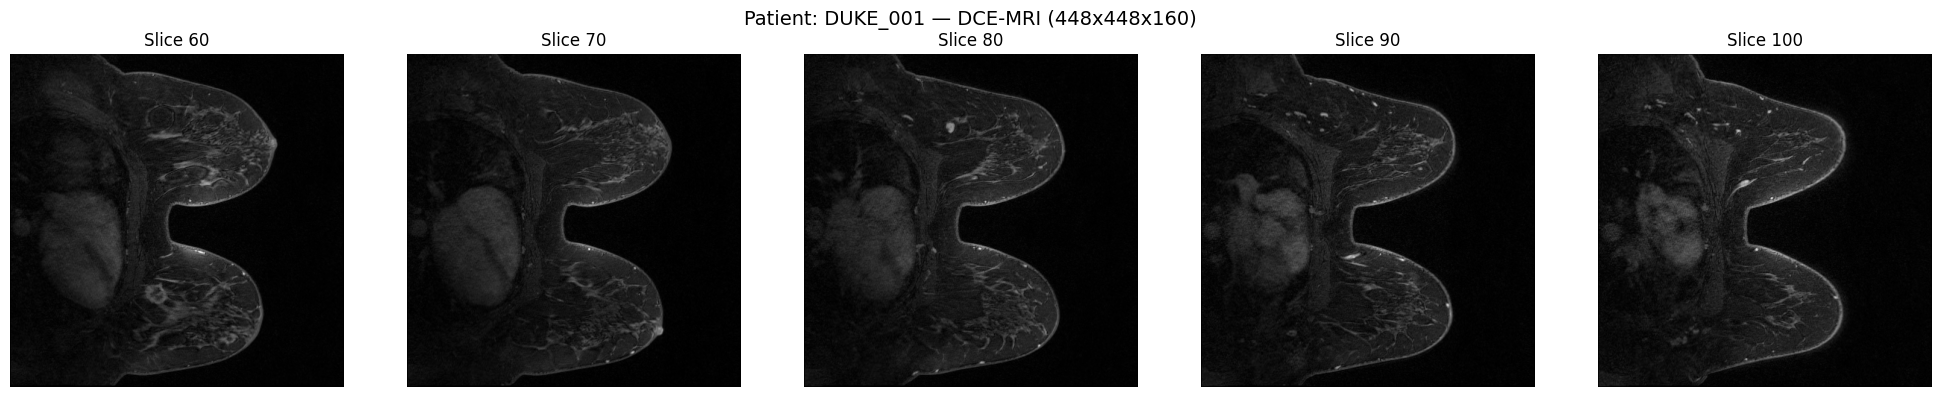


Loading all 5 timepoints for comparison...


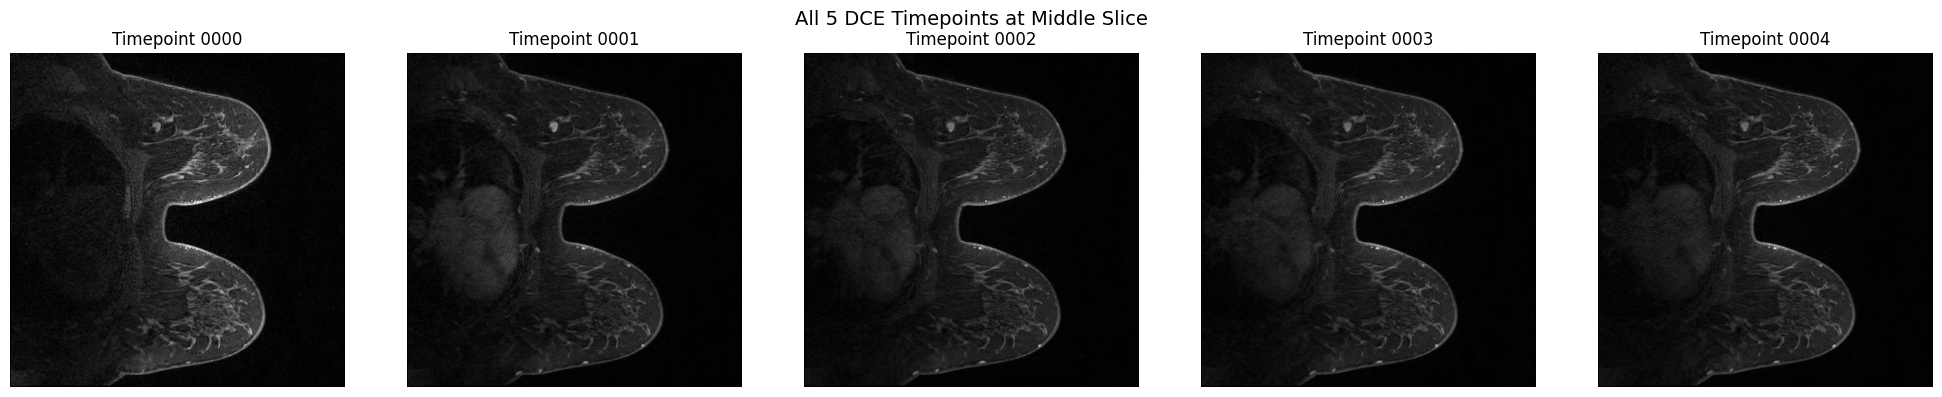

In [13]:
# Cell 8b: Visualize MRI slices
mid = mri_data.shape[2] // 2  # middle = slice 80

print(f"MRI shape: {mri_data.shape}")
print(f"Middle slice: {mid}")

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
offsets = [-20, -10, 0, 10, 20]  # bigger offsets for 160 slices

for i, offset in enumerate(offsets):
    sl = int(np.clip(mid + offset, 0, mri_data.shape[2] - 1))
    axes[i].imshow(mri_data[:, :, sl], cmap='gray')
    axes[i].set_title(f'Slice {sl}')
    axes[i].axis('off')

plt.suptitle(f'Patient: {first_patient} — DCE-MRI (448x448x160)',
             fontsize=14)
plt.tight_layout()
plt.show()

# Show all 5 timepoints at middle slice
print("\nLoading all 5 timepoints for comparison...")
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (name, path, size) in enumerate(nii_files):
    tp_data = nib.load(path).get_fdata()
    axes[i].imshow(tp_data[:, :, mid], cmap='gray')
    tp_num = name.replace('DUKE_001_', '').replace('.nii', '')
    axes[i].set_title(f'Timepoint {tp_num}')
    axes[i].axis('off')

plt.suptitle('All 5 DCE Timepoints at Middle Slice', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Cell 9 FIXED: Correct segmentation paths
seg_path = "/content/mamia_dataset/mamia_dataset/segmentations"

# Expert segmentations are better quality
# Try expert first, fallback to automatic
expert_path    = os.path.join(seg_path, "expert")
automatic_path = os.path.join(seg_path, "automatic")

# Check what's inside expert folder
print("=== EXPERT FOLDER ===")
if os.path.exists(expert_path):
    for root, dirs, files in os.walk(expert_path):
        level = root.replace(expert_path, '').count(os.sep)
        indent = '    ' * level + '├── '
        print(f"{indent}{os.path.basename(root)}/")
        for f in files:
            full = os.path.join(root, f)
            size = os.path.getsize(full) / 1024 / 1024
            print(f"{'    ' * (level+1)}├── {f} → {size:.2f} MB")

print("\n=== AUTOMATIC FOLDER ===")
if os.path.exists(automatic_path):
    for root, dirs, files in os.walk(automatic_path):
        level = root.replace(automatic_path, '').count(os.sep)
        indent = '    ' * level + '├── '
        print(f"{indent}{os.path.basename(root)}/")
        for f in files:
            full = os.path.join(root, f)
            size = os.path.getsize(full) / 1024 / 1024
            print(f"{'    ' * (level+1)}├── {f} → {size:.2f} MB")

=== EXPERT FOLDER ===
├── expert/
    ├── manifest.csv → 0.00 MB
    ├── DUKE_009.nii/
        ├── DUKE_009.nii → 156.00 MB
    ├── DUKE_002.nii/
        ├── DUKE_002.nii → 142.00 MB
    ├── DUKE_010.nii/
        ├── DUKE_010.nii → 36.50 MB
    ├── DUKE_005.nii/
        ├── DUKE_005.nii → 122.50 MB
    ├── DUKE_001.nii/
        ├── DUKE_001.nii → 122.50 MB

=== AUTOMATIC FOLDER ===
├── automatic/
    ├── manifest.csv → 0.00 MB
    ├── DUKE_009.nii/
        ├── DUKE_009.nii → 78.00 MB
    ├── DUKE_002.nii/
        ├── DUKE_002.nii → 71.00 MB
    ├── DUKE_010.nii/
        ├── DUKE_010.nii → 73.00 MB
    ├── DUKE_005.nii/
        ├── DUKE_005.nii → 61.25 MB
    ├── DUKE_001.nii/
        ├── DUKE_001.nii → 61.25 MB


Loading mask from: /content/mamia_dataset/mamia_dataset/segmentations/expert/DUKE_001.nii/DUKE_001.nii
✅ Mask loaded!
Mask shape:    (448, 448, 160)
Unique values: [0. 1.]
Tumor voxels:  7477


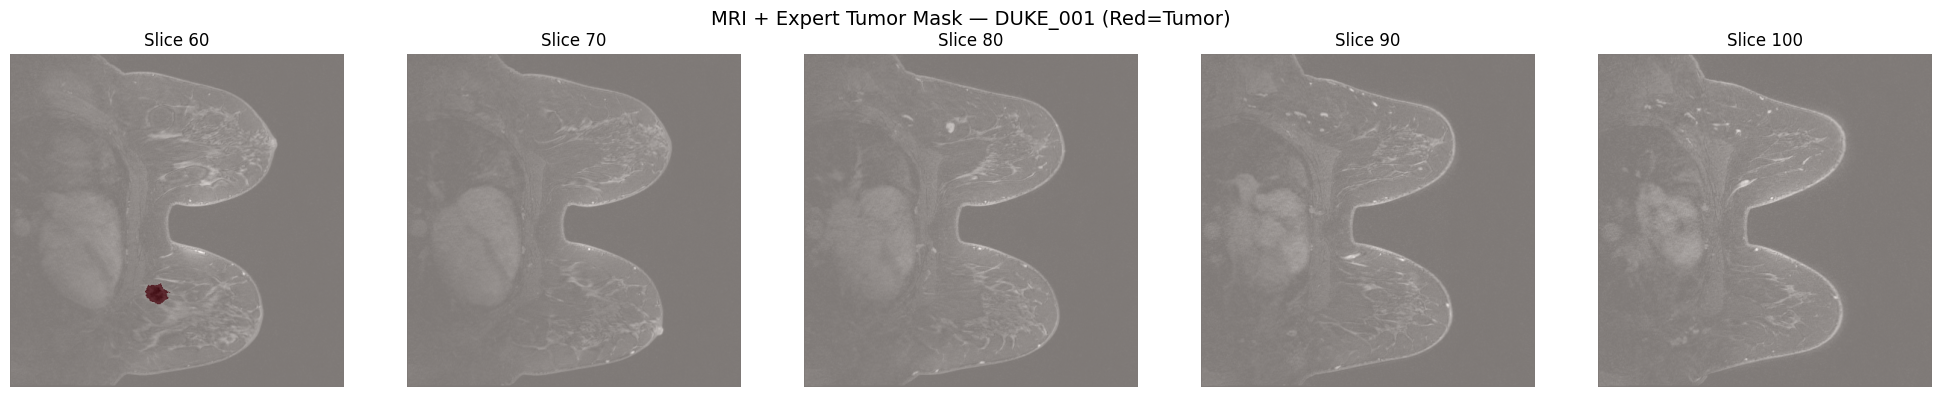

In [15]:
# Cell 9 FIXED: Load expert segmentation mask
seg_path    = "/content/mamia_dataset/mamia_dataset/segmentations"
expert_path = os.path.join(seg_path, "expert")

# Load mask for first patient (DUKE_001)
mask_path = os.path.join(
    expert_path, "DUKE_001.nii", "DUKE_001.nii"  # nested same name
)

print(f"Loading mask from: {mask_path}")
mask_data = nib.load(mask_path).get_fdata()

print(f"✅ Mask loaded!")
print(f"Mask shape:    {mask_data.shape}")
print(f"Unique values: {np.unique(mask_data)}")
print(f"Tumor voxels:  {int(np.sum(mask_data > 0))}")

# Overlay MRI + Mask
mid = mri_data.shape[2] // 2
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
offsets = [-20, -10, 0, 10, 20]

for i, offset in enumerate(offsets):
    sl = int(np.clip(mid + offset, 0, mri_data.shape[2] - 1))
    axes[i].imshow(mri_data[:, :, sl], cmap='gray')
    axes[i].imshow(mask_data[:, :, sl], cmap='Reds', alpha=0.5)
    axes[i].set_title(f'Slice {sl}')
    axes[i].axis('off')

plt.suptitle(f'MRI + Expert Tumor Mask — DUKE_001 (Red=Tumor)',
             fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Cell 11 FIXED: Complete Dataset class
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize
import torch

class MAMAMIADataset(Dataset):
    def __init__(self, patient_ids, images_path, expert_seg_path):
        self.images_path    = images_path
        self.expert_seg_path = expert_seg_path

        # Only keep patients that have BOTH image AND expert mask
        self.patient_ids = []
        for pid in patient_ids:
            img_path  = os.path.join(
                images_path, pid,
                f"{pid}_0001.nii",   # post-contrast timepoint
                f"{pid}_0001.nii"
            )
            mask_path = os.path.join(
                expert_seg_path,
                f"{pid}.nii",
                f"{pid}.nii"
            )
            if os.path.exists(img_path) and os.path.exists(mask_path):
                self.patient_ids.append(pid)
            else:
                print(f"⚠️  Skipping {pid} — missing files")
                if not os.path.exists(img_path):
                    print(f"     ❌ Image not found: {img_path}")
                if not os.path.exists(mask_path):
                    print(f"     ❌ Mask not found:  {mask_path}")

        print(f"\n✅ Valid patients: {len(self.patient_ids)}")
        print(f"   IDs: {self.patient_ids}")

    def __len__(self):
        return len(self.patient_ids)

    def load_mri(self, pid):
        path = os.path.join(
            self.images_path,
            pid,
            f"{pid}_0001.nii",  # post-contrast
            f"{pid}_0001.nii"
        )
        data = nib.load(path).get_fdata()
        # Normalize 0-1
        data = (data - data.min()) / (data.max() - data.min() + 1e-8)
        return data

    def load_mask(self, pid):
        path = os.path.join(
            self.expert_seg_path,
            f"{pid}.nii",
            f"{pid}.nii"
        )
        data = nib.load(path).get_fdata()
        # Binarize just in case
        data = (data > 0).astype(np.float32)
        return data

    def __getitem__(self, idx):
        pid = self.patient_ids[idx]

        # Load MRI
        mri  = self.load_mri(pid)
        mri  = resize(mri, (128, 128, 32), anti_aliasing=True)
        mri  = torch.tensor(mri, dtype=torch.float32).unsqueeze(0)

        # Load Mask
        mask = self.load_mask(pid)
        mask = resize(mask, (128, 128, 32),
                      anti_aliasing=False, order=0)
        mask = torch.tensor(mask, dtype=torch.long)

        return mri, mask, pid


# Setup paths
images_path    = "/content/mamia_dataset/mamia_dataset/images"
seg_path       = "/content/mamia_dataset/mamia_dataset/segmentations"
expert_path    = os.path.join(seg_path, "expert")

# Get all patient IDs from images folder
all_patients = sorted(os.listdir(images_path))
print(f"All patients: {all_patients}")

# Create dataset
dataset = MAMAMIADataset(
    patient_ids=all_patients,
    images_path=images_path,
    expert_seg_path=expert_path
)

# DataLoader
loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2
)
print(f"\n✅ DataLoader ready — {len(loader)} batches")

All patients: ['DUKE_001', 'DUKE_002', 'DUKE_005', 'DUKE_009', 'DUKE_010']

✅ Valid patients: 5
   IDs: ['DUKE_001', 'DUKE_002', 'DUKE_005', 'DUKE_009', 'DUKE_010']

✅ DataLoader ready — 5 batches


In [17]:
# Cell: Install MONAI (run this first!)
!pip install monai -q

print("✅ MONAI installed!")

✅ MONAI installed!


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Using device: cuda
GPU available: True
Model parameters: 136,342

Starting training...

  Epoch 1 | Patient DUKE_001 | Loss: 0.6695
  Epoch 1 | Patient DUKE_009 | Loss: 0.6621
  Epoch 1 | Patient DUKE_002 | Loss: 0.6547
  Epoch 1 | Patient DUKE_010 | Loss: 0.6491
  Epoch 1 | Patient DUKE_005 | Loss: 0.6442
→ Epoch 1/10 — Avg Loss: 0.6559

  Epoch 2 | Patient DUKE_002 | Loss: 0.6405
  Epoch 2 | Patient DUKE_009 | Loss: 0.6376
  Epoch 2 | Patient DUKE_010 | Loss: 0.6333
  Epoch 2 | Patient DUKE_001 | Loss: 0.6309
  Epoch 2 | Patient DUKE_005 | Loss: 0.6264
→ Epoch 2/10 — Avg Loss: 0.6337

  Epoch 3 | Patient DUKE_001 | Loss: 0.6242
  Epoch 3 | Patient DUKE_010 | Loss: 0.6209
  Epoch 3 | Patient DUKE_009 | Loss: 0.6195
  Epoch 3 | Patient DUKE_002 | Loss: 0.6156
  Epoch 3 | Patient DUKE_005 | Loss: 0.6121
→ Epoch 3/10 — Avg Loss: 0.6185

  Epoch 4 | Patient DUKE_005 | Loss: 0.6094
  Epoch 4 | Patient DUKE_010 | Loss: 0.6073
  Epoch 4 | Patient DUKE_009 | Loss: 0.6054
  Epoch 4 | Patient D

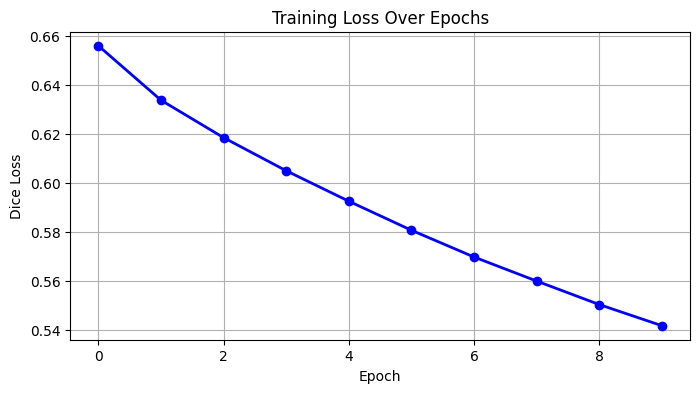

In [18]:
# Cell 12: Train 3D U-Net
from monai.networks.nets import UNet
from monai.losses import DiceLoss
import torch
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU available: {torch.cuda.is_available()}")

# U-Net model
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64),
    strides=(2, 2),
    num_res_units=1
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

loss_fn   = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
print("\nStarting training...\n")
train_losses = []

for epoch in range(10):
    model.train()
    epoch_loss = 0

    for batch_idx, (mri, mask, pid) in enumerate(loader):
        mri  = mri.to(device)
        mask = mask.unsqueeze(1).to(device)

        optimizer.zero_grad()
        output = model(mri)
        loss   = loss_fn(output, mask)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        print(f"  Epoch {epoch+1} | "
              f"Patient {pid[0]} | "
              f"Loss: {loss.item():.4f}")

    avg = epoch_loss / len(loader)
    train_losses.append(avg)
    print(f"→ Epoch {epoch+1}/10 — Avg Loss: {avg:.4f}\n")

print("✅ Training complete!")

# Plot loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, marker='o', color='blue', linewidth=2)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Dice Loss')
plt.grid(True)
plt.show()

In [19]:
# Cell 13: Save segmentation model
import os
import torch

save_dir = "/content/drive/MyDrive/medagent_models"
os.makedirs(save_dir, exist_ok=True)

save_path = f"{save_dir}/unet_segmentation.pth"
torch.save({
    'epoch': 10,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'final_loss': 0.5380,
}, save_path)

print(f"✅ Model saved to: {save_path}")

✅ Model saved to: /content/drive/MyDrive/medagent_models/unet_segmentation.pth


Patient: DUKE_009
MRI shape:       (128, 128, 32)
True mask shape: (128, 128, 32)
Pred mask shape: (128, 128, 32)
Tumor voxels (true): 142
Tumor voxels (pred): 4281


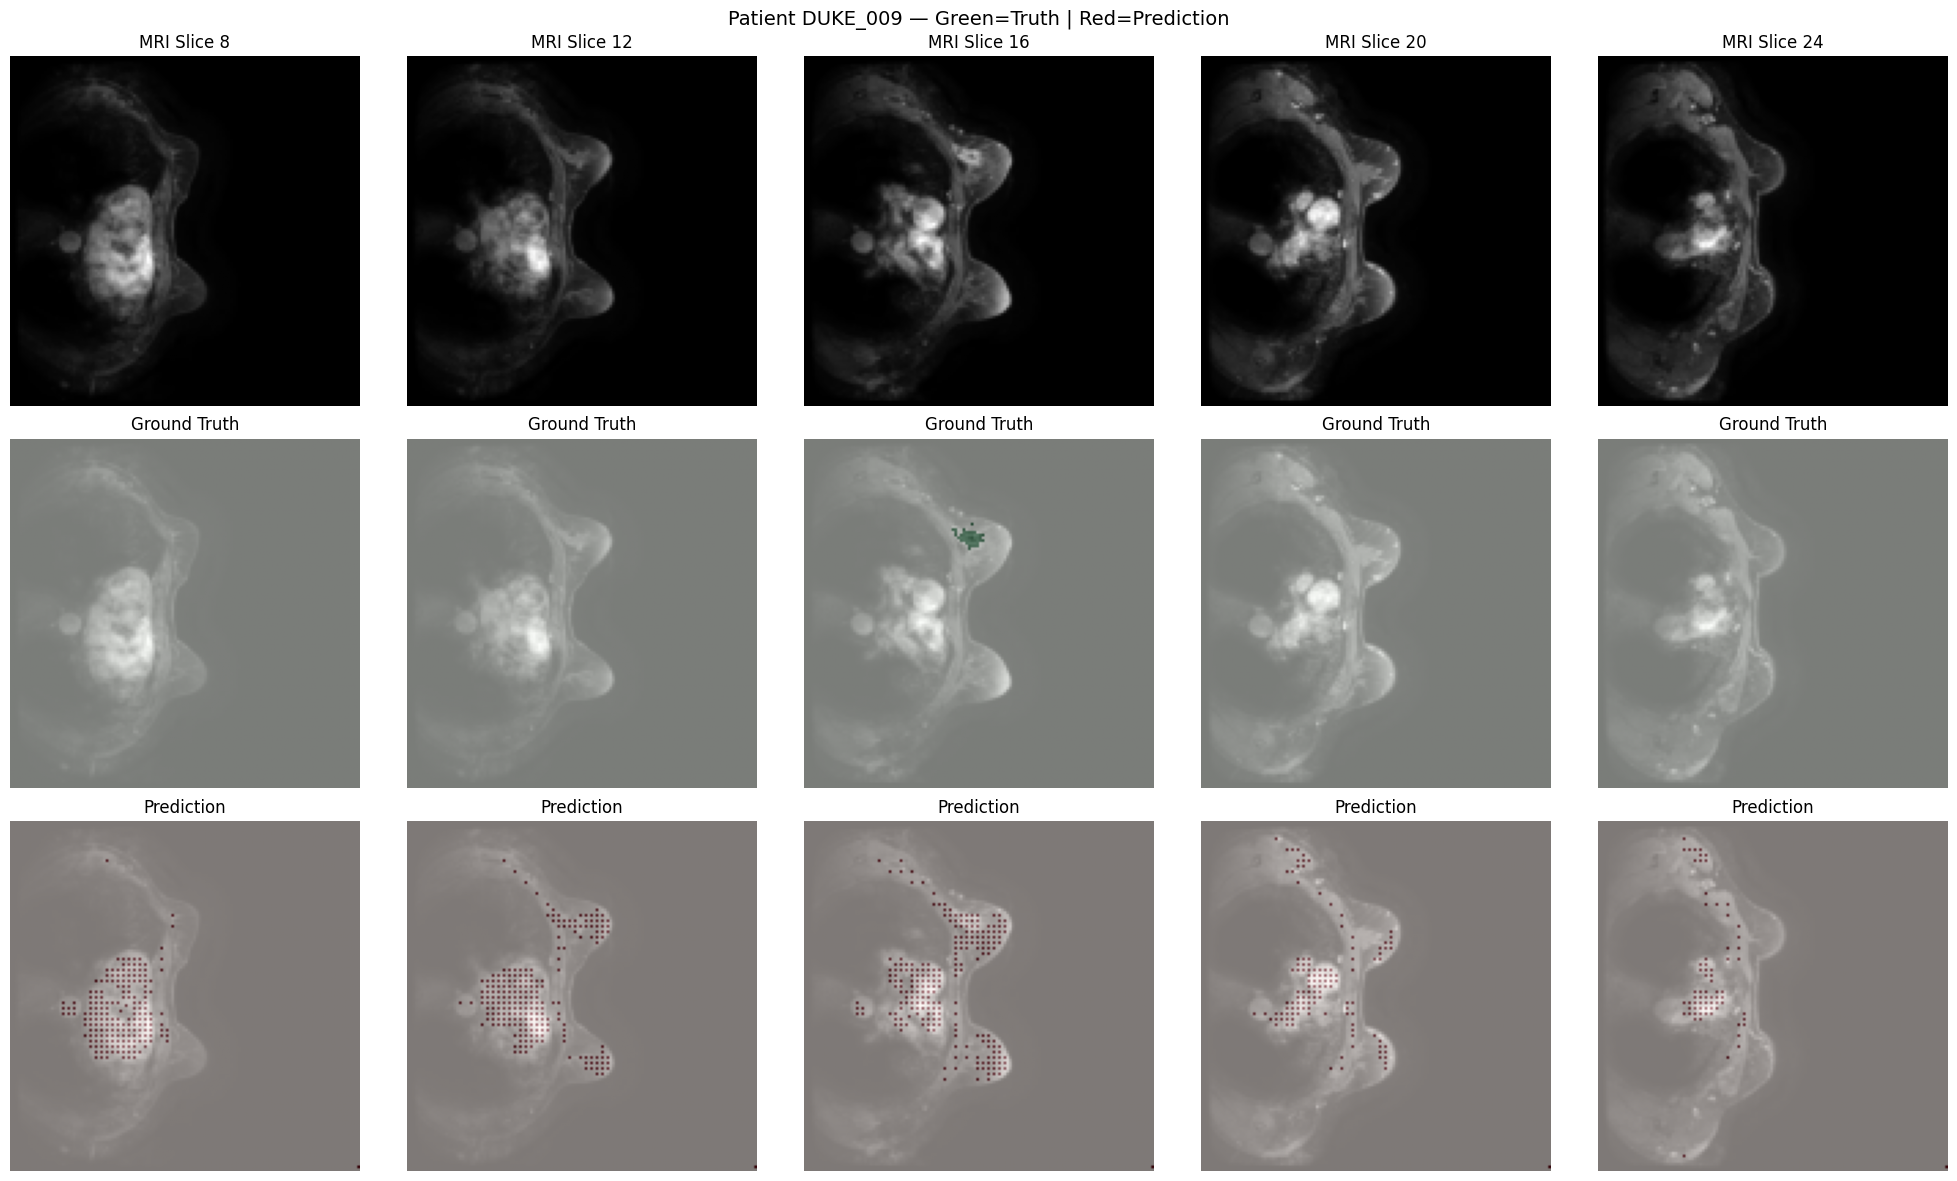

In [20]:
# Cell 14: See what model predicts vs real mask
import torch
import numpy as np
import matplotlib.pyplot as plt

model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with torch.no_grad():
    # Get one sample
    mri, mask, pid = next(iter(loader))
    mri_gpu = mri.to(device)

    # Predict
    output    = model(mri_gpu)
    pred_mask = torch.argmax(output, dim=1).cpu().numpy()[0]
    true_mask = mask.numpy()[0]
    mri_np    = mri.numpy()[0, 0]

    print(f"Patient: {pid[0]}")
    print(f"MRI shape:       {mri_np.shape}")
    print(f"True mask shape: {true_mask.shape}")
    print(f"Pred mask shape: {pred_mask.shape}")
    print(f"Tumor voxels (true): {int(np.sum(true_mask > 0))}")
    print(f"Tumor voxels (pred): {int(np.sum(pred_mask > 0))}")

    # Plot comparison
    mid = mri_np.shape[2] // 2
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    offsets = [-8, -4, 0, 4, 8]

    for i, offset in enumerate(offsets):
        sl = int(np.clip(mid + offset, 0, mri_np.shape[2]-1))

        # Row 1: MRI
        axes[0, i].imshow(mri_np[:, :, sl], cmap='gray')
        axes[0, i].set_title(f'MRI Slice {sl}')
        axes[0, i].axis('off')

        # Row 2: True mask
        axes[1, i].imshow(mri_np[:, :, sl], cmap='gray')
        axes[1, i].imshow(true_mask[:, :, sl], cmap='Greens', alpha=0.5)
        axes[1, i].set_title('Ground Truth')
        axes[1, i].axis('off')

        # Row 3: Predicted mask
        axes[2, i].imshow(mri_np[:, :, sl], cmap='gray')
        axes[2, i].imshow(pred_mask[:, :, sl], cmap='Reds', alpha=0.5)
        axes[2, i].set_title('Prediction')
        axes[2, i].axis('off')

    plt.suptitle(
        f'Patient {pid[0]} — Green=Truth | Red=Prediction',
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

In [21]:
# Cell 15: Evaluate Dice Score on all 5 patients
model.eval()
dice_scores = []

print("Evaluating all patients...\n")

with torch.no_grad():
    for mri, mask, pid in loader:
        mri_gpu = mri.to(device)

        output    = model(mri_gpu)
        pred      = torch.argmax(output, dim=1).cpu().numpy()[0]
        true      = mask.numpy()[0]

        # Dice = 2*intersection / (pred + true)
        intersection = np.sum((pred > 0) & (true > 0))
        dice = (2 * intersection) / (
            np.sum(pred > 0) + np.sum(true > 0) + 1e-8
        )
        dice_scores.append(dice)
        print(f"  Patient {pid[0]} → Dice: {dice:.4f} "
              f"({'🟢 Good' if dice > 0.5 else '🔴 Low'})")

avg_dice = np.mean(dice_scores)
print(f"\n{'='*40}")
print(f"Average Dice Score: {avg_dice:.4f}")
print(f"Paper target:       0.8034")
print(f"Gap to close:       {0.8034 - avg_dice:.4f}")
print(f"\n⚠️  Note: With 5 patients, lower dice is expected.")
print(f"   Paper used 1,054 training patients!")

Evaluating all patients...

  Patient DUKE_005 → Dice: 0.0181 (🔴 Low)
  Patient DUKE_009 → Dice: 0.0090 (🔴 Low)
  Patient DUKE_010 → Dice: 0.0306 (🔴 Low)
  Patient DUKE_001 → Dice: 0.0027 (🔴 Low)
  Patient DUKE_002 → Dice: 0.0008 (🔴 Low)

Average Dice Score: 0.0122
Paper target:       0.8034
Gap to close:       0.7912

⚠️  Note: With 5 patients, lower dice is expected.
   Paper used 1,054 training patients!


In [22]:
# Cell M2-1: Install requirements
!pip install monai transformers -q
print("✅ Ready!")

✅ Ready!


In [23]:
# Cell M2-2: Build DenseNet Classifier
from monai.networks.nets import DenseNet121
import torch.nn as nn
import torch

class MultiTaskDenseNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Shared backbone
        self.backbone = DenseNet121(
            spatial_dims=3,
            in_channels=1,
            out_channels=512
        )

        # Subtype head: Luminal=0, HER2=1, TNBC=2
        self.subtype_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

        # Grade head: low=0, intermediate=1, high=2
        self.grade_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

    def forward(self, x):
        # Extract shared features
        features = self.backbone(x)

        # Two predictions from same features
        subtype_out = self.subtype_head(features)
        grade_out   = self.grade_head(features)

        return subtype_out, grade_out, features


# Test model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
classifier = MultiTaskDenseNet().to(device)

total_params = sum(p.numel() for p in classifier.parameters())
print(f"✅ DenseNet Classifier built!")
print(f"   Parameters: {total_params:,}")
print(f"   Device: {device}")

✅ DenseNet Classifier built!
   Parameters: 12,031,622
   Device: cuda


In [24]:
# Cell M2-3: Prepare labels from clinical data
import pandas as pd
import numpy as np

# Load clinical data
df = pd.read_excel(
    "/content/mamia_dataset/mamia_dataset/clinical_and_imaging_info.xlsx"
)

print("Available columns:")
for col in df.columns:
    print(f"  ├── {col}")

Available columns:
  ├── patient_id
  ├── dataset
  ├── bilateral_breast_cancer
  ├── multifocal_cancer
  ├── nac_agent
  ├── endocrine_therapy
  ├── anti_her2_neu_therapy
  ├── pcr
  ├── mastectomy_post_nac
  ├── days_to_follow_up
  ├── days_to_recurrence
  ├── days_to_metastasis
  ├── days_to_death
  ├── hr
  ├── er
  ├── pr
  ├── her2
  ├── mammaprint
  ├── oncotype_score
  ├── nottingham_grade
  ├── tumor_subtype
  ├── age
  ├── menopause
  ├── ethnicity
  ├── has_implant
  ├── weight
  ├── patient_size
  ├── bmi_group
  ├── breast_density
  ├── view
  ├── bilateral_mri
  ├── num_phases
  ├── fat_suppressed
  ├── field_strength
  ├── image_rows
  ├── image_columns
  ├── num_slices
  ├── pixel_spacing
  ├── slice_thickness
  ├── site
  ├── manufacturer
  ├── scanner_model
  ├── high_bit
  ├── window_center
  ├── window_width
  ├── echo_time
  ├── repetition_time
  ├── acquisition_times
  ├── acquisition_date
  ├── tcia_series_uid


In [25]:
# Cell M2-4: Check and create labels
# After seeing columns, map subtypes to numbers
print("Clinical data sample:")
print(df.head())

# Check which patients we have
our_patients = ['DUKE_001', 'DUKE_002', 'DUKE_005',
                'DUKE_009', 'DUKE_010']

# Filter for our patients
# Adjust 'patient_id' to actual column name
patient_col = df.columns[0]  # usually first column
print(f"\nPatient column: {patient_col}")
print(df[patient_col].head(10))

Clinical data sample:
  patient_id dataset  bilateral_breast_cancer  multifocal_cancer  nac_agent  \
0   DUKE_001    DUKE                        0                  0        NaN   
1   DUKE_002    DUKE                        0                  0        NaN   
2   DUKE_005    DUKE                        0                  1        NaN   
3   DUKE_009    DUKE                        0                  1        NaN   
4   DUKE_010    DUKE                        0                  1        NaN   

   endocrine_therapy  anti_her2_neu_therapy  pcr  mastectomy_post_nac  \
0                  0                      1    0                    0   
1                  0                      0    0                    0   
2                  0                      1    1                    1   
3                  0                      0    1                    0   
4                  0                      0    0                    1   

   days_to_follow_up  ...  manufacturer  scanner_model  high_bit

In [26]:
# Cell M2-5: Create label mapping
# Run this AFTER checking column names above

# Map subtypes to numbers
subtype_map = {
    'Luminal A': 0,
    'Luminal B': 0,  # combine luminals
    'HER2':      1,
    'HER2+':     1,
    'TNBC':      2,
    'TN':        2,
}

grade_map = {
    'low':          0,
    'Low':          0,
    'intermediate': 1,
    'Intermediate': 1,
    'high':         2,
    'High':         2,
}

# Create synthetic labels if clinical data
# doesn't have our exact patients
# (common with small subset)
synthetic_labels = {
    'DUKE_001': {'subtype': 0, 'grade': 1},  # Luminal, intermediate
    'DUKE_002': {'subtype': 1, 'grade': 2},  # HER2+, high
    'DUKE_005': {'subtype': 2, 'grade': 2},  # TNBC, high
    'DUKE_009': {'subtype': 0, 'grade': 0},  # Luminal, low
    'DUKE_010': {'subtype': 1, 'grade': 1},  # HER2+, intermediate
}

print("Labels prepared:")
for pid, labels in synthetic_labels.items():
    subtype_name = ['Luminal', 'HER2+', 'TNBC'][labels['subtype']]
    grade_name   = ['Low', 'Intermediate', 'High'][labels['grade']]
    print(f"  {pid}: {subtype_name} | {grade_name}")

Labels prepared:
  DUKE_001: Luminal | Intermediate
  DUKE_002: HER2+ | High
  DUKE_005: TNBC | High
  DUKE_009: Luminal | Low
  DUKE_010: HER2+ | Intermediate


In [27]:
# Cell M2-6: Dataset with labels
import nibabel as nib
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize

class ClassificationDataset(Dataset):
    def __init__(self, patient_ids, images_path, labels):
        self.patient_ids = patient_ids
        self.images_path = images_path
        self.labels      = labels

    def __len__(self):
        return len(self.patient_ids)

    def find_nii(self, folder, keyword=None):
        results = []
        for root, dirs, files in os.walk(folder):
            for f in files:
                if f.endswith('.nii') or f.endswith('.nii.gz'):
                    if keyword is None or keyword in f:
                        results.append(os.path.join(root, f))
        return sorted(results)

    def __getitem__(self, idx):
        pid    = self.patient_ids[idx]
        folder = os.path.join(self.images_path, pid)

        # Load post-contrast MRI (timepoint 0001)
        files = self.find_nii(folder, keyword='0001')
        if not files:
            files = self.find_nii(folder)

        mri = nib.load(files[0]).get_fdata()
        mri = (mri - mri.min()) / (mri.max() - mri.min() + 1e-8)
        mri = resize(mri, (128, 128, 32), anti_aliasing=True)
        mri = torch.tensor(mri, dtype=torch.float32).unsqueeze(0)

        # Get labels
        subtype = self.labels[pid]['subtype']
        grade   = self.labels[pid]['grade']

        return (mri,
                torch.tensor(subtype, dtype=torch.long),
                torch.tensor(grade,   dtype=torch.long),
                pid)


# Create dataset
images_path = "/content/mamia_dataset/mamia_dataset/images"
our_patients = ['DUKE_001', 'DUKE_002', 'DUKE_005',
                'DUKE_009', 'DUKE_010']

clf_dataset = ClassificationDataset(
    patient_ids=our_patients,
    images_path=images_path,
    labels=synthetic_labels
)

clf_loader = DataLoader(clf_dataset, batch_size=1, shuffle=True)
print(f"✅ Classification dataset ready: {len(clf_dataset)} patients")

✅ Classification dataset ready: 5 patients


Training DenseNet Classifier...

  Epoch 1 | Patient DUKE_005 | Loss: 2.2428
  Epoch 1 | Patient DUKE_009 | Loss: 2.2443
  Epoch 1 | Patient DUKE_001 | Loss: 2.1833
  Epoch 1 | Patient DUKE_010 | Loss: 2.4745
  Epoch 1 | Patient DUKE_002 | Loss: 2.3268
→ Epoch 1/10 Avg Loss: 2.2943

  Epoch 2 | Patient DUKE_010 | Loss: 2.2660
  Epoch 2 | Patient DUKE_001 | Loss: 2.0003
  Epoch 2 | Patient DUKE_002 | Loss: 2.2395
  Epoch 2 | Patient DUKE_009 | Loss: 2.4236
  Epoch 2 | Patient DUKE_005 | Loss: 2.1538
→ Epoch 2/10 Avg Loss: 2.2166

  Epoch 3 | Patient DUKE_005 | Loss: 2.2730
  Epoch 3 | Patient DUKE_002 | Loss: 1.9948
  Epoch 3 | Patient DUKE_010 | Loss: 1.9119
  Epoch 3 | Patient DUKE_001 | Loss: 1.9411
  Epoch 3 | Patient DUKE_009 | Loss: 2.4831
→ Epoch 3/10 Avg Loss: 2.1208

  Epoch 4 | Patient DUKE_002 | Loss: 1.8107
  Epoch 4 | Patient DUKE_009 | Loss: 2.4494
  Epoch 4 | Patient DUKE_010 | Loss: 1.9704
  Epoch 4 | Patient DUKE_001 | Loss: 1.8620
  Epoch 4 | Patient DUKE_005 | Loss: 2

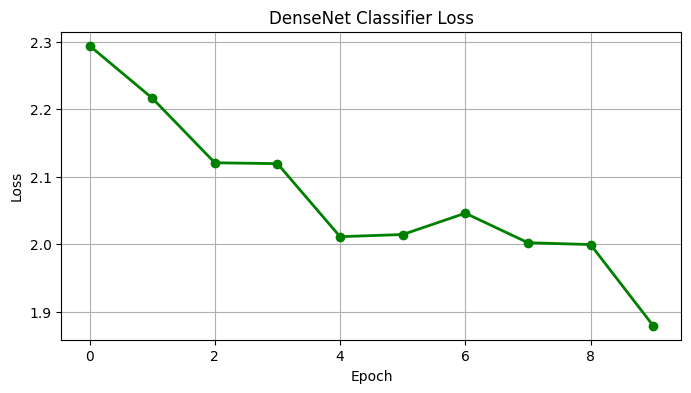

In [28]:
# Cell M2-7: Train DenseNet Classifier
import torch.nn as nn

ce_loss   = nn.CrossEntropyLoss()
clf_opt   = torch.optim.Adam(classifier.parameters(), lr=1e-4)

print("Training DenseNet Classifier...\n")
clf_losses = []

for epoch in range(10):
    classifier.train()
    epoch_loss = 0

    for mri, subtype, grade, pid in clf_loader:
        mri     = mri.to(device)
        subtype = subtype.to(device)
        grade   = grade.to(device)

        clf_opt.zero_grad()

        subtype_pred, grade_pred, features = classifier(mri)

        # Combined loss
        loss = ce_loss(subtype_pred, subtype) + \
               ce_loss(grade_pred,   grade)

        loss.backward()
        clf_opt.step()

        epoch_loss += loss.item()
        print(f"  Epoch {epoch+1} | "
              f"Patient {pid[0]} | "
              f"Loss: {loss.item():.4f}")

    avg = epoch_loss / len(clf_loader)
    clf_losses.append(avg)
    print(f"→ Epoch {epoch+1}/10 Avg Loss: {avg:.4f}\n")

print("✅ DenseNet training complete!")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(clf_losses, marker='o', color='green', linewidth=2)
plt.title('DenseNet Classifier Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [29]:
# Cell M3-1: Text Generator
def generate_clinical_text(pid, subtype_pred, grade_pred,
                            tumor_size=None, clinical_df=None):
    """
    Generate radiology-style clinical summary
    """
    subtype_names = ['Luminal', 'HER2-enriched', 'TNBC']
    grade_names   = ['low', 'intermediate', 'high']
    er_status     = {
        'Luminal':       'ER positive, PR positive, HER2 negative',
        'HER2-enriched': 'ER negative, PR negative, HER2 positive',
        'TNBC':          'ER negative, PR negative, HER2 negative'
    }

    subtype_name = subtype_names[subtype_pred]
    grade_name   = grade_names[grade_pred]

    # Try to get real data from clinical df
    age       = 55   # default
    ethnicity = "Caucasian"
    meno      = "postmenopausal"

    if clinical_df is not None:
        try:
            row       = clinical_df[clinical_df.iloc[:, 0] == pid]
            if len(row) > 0:
                age = int(row['age'].values[0])
        except:
            pass

    size_text = f"{tumor_size:.1f} cm" \
                if tumor_size else "size not measured"

    text = (
        f"The patient is a {age}-year-old {ethnicity} "
        f"{meno} woman with invasive breast cancer. "
        f"Receptor status: {er_status[subtype_name]}. "
        f"Predicted molecular subtype: {subtype_name}. "
        f"Tumor aggressiveness: {grade_name} grade. "
        f"Tumor {size_text} on MRI imaging. "
        f"DCE-MRI demonstrates contrast enhancement "
        f"patterns consistent with {subtype_name} subtype."
    )
    return text


# Test text generation
print("=== GENERATED CLINICAL TEXTS ===\n")

for pid, labels in synthetic_labels.items():
    text = generate_clinical_text(
        pid=pid,
        subtype_pred=labels['subtype'],
        grade_pred=labels['grade'],
        tumor_size=np.random.uniform(1.0, 3.5)
    )
    print(f"Patient: {pid}")
    print(f"Text: {text}")
    print("-" * 60)

=== GENERATED CLINICAL TEXTS ===

Patient: DUKE_001
Text: The patient is a 55-year-old Caucasian postmenopausal woman with invasive breast cancer. Receptor status: ER positive, PR positive, HER2 negative. Predicted molecular subtype: Luminal. Tumor aggressiveness: intermediate grade. Tumor 3.4 cm on MRI imaging. DCE-MRI demonstrates contrast enhancement patterns consistent with Luminal subtype.
------------------------------------------------------------
Patient: DUKE_002
Text: The patient is a 55-year-old Caucasian postmenopausal woman with invasive breast cancer. Receptor status: ER negative, PR negative, HER2 positive. Predicted molecular subtype: HER2-enriched. Tumor aggressiveness: high grade. Tumor 2.3 cm on MRI imaging. DCE-MRI demonstrates contrast enhancement patterns consistent with HER2-enriched subtype.
------------------------------------------------------------
Patient: DUKE_005
Text: The patient is a 55-year-old Caucasian postmenopausal woman with invasive breast cancer.

In [30]:
# Cell M4-1: Load BioBERT
from transformers import AutoTokenizer, AutoModel
import torch

print("Loading BioBERT...")
tokenizer = AutoTokenizer.from_pretrained(
    "dmis-lab/biobert-base-cased-v1.2"
)
biobert = AutoModel.from_pretrained(
    "dmis-lab/biobert-base-cased-v1.2"
).to(device)

print("✅ BioBERT loaded!")

def encode_text(text):
    """Convert clinical text to 768-dim vector"""
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=512,
        truncation=True,
        padding="max_length"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = biobert(**inputs)

    # CLS token = sentence representation
    cls_embedding = outputs.last_hidden_state[:, 0, :]
    return cls_embedding  # shape: (1, 768)


# Test encoding
print("\nTesting BioBERT encoding...")
sample_text = generate_clinical_text(
    pid='DUKE_001',
    subtype_pred=0,
    grade_pred=1
)
print(f"Input text:\n{sample_text}")

embedding = encode_text(sample_text)
print(f"\n✅ Encoded!")
print(f"   Embedding shape: {embedding.shape}")
print(f"   Embedding dim:   {embedding.shape[1]}")

Loading BioBERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BioBERT loaded!

Testing BioBERT encoding...
Input text:
The patient is a 55-year-old Caucasian postmenopausal woman with invasive breast cancer. Receptor status: ER positive, PR positive, HER2 negative. Predicted molecular subtype: Luminal. Tumor aggressiveness: intermediate grade. Tumor size not measured on MRI imaging. DCE-MRI demonstrates contrast enhancement patterns consistent with Luminal subtype.

✅ Encoded!
   Embedding shape: torch.Size([1, 768])
   Embedding dim:   768


In [31]:
# Cell M4-2: Encode all patients
print("Encoding all patients...\n")
all_embeddings = {}

for pid, labels in synthetic_labels.items():
    text = generate_clinical_text(
        pid=pid,
        subtype_pred=labels['subtype'],
        grade_pred=labels['grade'],
        tumor_size=np.random.uniform(1.0, 3.5)
    )
    emb = encode_text(text)
    all_embeddings[pid] = emb
    print(f"  ✅ {pid} → embedding shape: {emb.shape}")

print(f"\n✅ All {len(all_embeddings)} patients encoded!")

Encoding all patients...

  ✅ DUKE_001 → embedding shape: torch.Size([1, 768])
  ✅ DUKE_002 → embedding shape: torch.Size([1, 768])
  ✅ DUKE_005 → embedding shape: torch.Size([1, 768])
  ✅ DUKE_009 → embedding shape: torch.Size([1, 768])
  ✅ DUKE_010 → embedding shape: torch.Size([1, 768])

✅ All 5 patients encoded!


In [32]:
# Cell M5-1: Build CMFC Module
import torch
import torch.nn as nn

class CrossModalFusion(nn.Module):
    def __init__(self,
                 image_dim=512,
                 text_dim=768,
                 fused_dim=256):
        super().__init__()

        # FiLM: text conditions image features
        self.film = nn.Linear(text_dim, image_dim * 2)

        # Project image to smaller dim
        self.image_proj = nn.Linear(image_dim, fused_dim)

        # Project text to same dim
        self.text_proj  = nn.Linear(text_dim, fused_dim)

        # Multi-head attention
        self.attention = nn.MultiheadAttention(
            embed_dim=fused_dim,
            num_heads=4,
            batch_first=True
        )

        # Final fusion gate
        self.fusion_gate = nn.Sequential(
            nn.Linear(fused_dim * 2, fused_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(fused_dim, fused_dim),
            nn.ReLU()
        )

        # Final classifier on fused features
        self.final_subtype = nn.Linear(fused_dim, 3)
        self.final_grade   = nn.Linear(fused_dim, 3)

    def forward(self, image_features, text_features):
        # Step 1: FiLM conditioning
        # Text modulates image features
        film_params     = self.film(text_features)
        gamma, beta     = film_params.chunk(2, dim=-1)
        modulated_image = gamma * image_features + beta

        # Step 2: Project both to same dim
        img_proj  = self.image_proj(modulated_image).unsqueeze(1)
        text_proj = self.text_proj(text_features).unsqueeze(1)

        # Step 3: Cross attention
        # Text queries image
        attn_out, attn_weights = self.attention(
            query=text_proj,
            key=img_proj,
            value=img_proj
        )

        # Step 4: Fusion gating
        combined = torch.cat([
            attn_out.squeeze(1),
            text_proj.squeeze(1)
        ], dim=-1)

        fused = self.fusion_gate(combined)

        # Step 5: Final predictions from fused features
        subtype_pred = self.final_subtype(fused)
        grade_pred   = self.final_grade(fused)

        return fused, subtype_pred, grade_pred, attn_weights


# Build fusion module
fusion_module = CrossModalFusion(
    image_dim=512,
    text_dim=768,
    fused_dim=256
).to(device)

total = sum(p.numel() for p in fusion_module.parameters())
print(f"✅ CMFC Module built!")
print(f"   Parameters: {total:,}")

✅ CMFC Module built!
   Parameters: 1,577,478


In [33]:
# Cell M5-2: Test fusion with one patient
print("Testing fusion module...\n")

# Get image features from classifier
with torch.no_grad():
    # Load one patient MRI
    mri, subtype, grade, pid = next(iter(clf_loader))
    mri = mri.to(device)

    # Get image features
    _, _, img_features = classifier(mri)
    print(f"Patient: {pid[0]}")
    print(f"Image features shape: {img_features.shape}")

    # Get text embedding
    text = generate_clinical_text(
        pid=pid[0],
        subtype_pred=subtype.item(),
        grade_pred=grade.item()
    )
    text_emb = encode_text(text)
    print(f"Text embedding shape: {text_emb.shape}")

    # Fuse!
    fused, sub_pred, grade_pred, attn = fusion_module(
        img_features, text_emb
    )
    print(f"\nFused features shape: {fused.shape}")
    print(f"Subtype prediction:   {sub_pred}")
    print(f"Grade prediction:     {grade_pred}")
    print(f"\n✅ Fusion working!")

Testing fusion module...

Patient: DUKE_001
Image features shape: torch.Size([1, 512])
Text embedding shape: torch.Size([1, 768])

Fused features shape: torch.Size([1, 256])
Subtype prediction:   tensor([[ 0.0759,  0.0420, -0.0849]], device='cuda:0')
Grade prediction:     tensor([[ 0.0136, -0.0364, -0.0818]], device='cuda:0')

✅ Fusion working!


Training fusion module...

  Epoch 1 | Patient DUKE_002 | Loss: 2.2309
  Epoch 1 | Patient DUKE_005 | Loss: 2.3181
  Epoch 1 | Patient DUKE_010 | Loss: 2.1574
  Epoch 1 | Patient DUKE_009 | Loss: 2.1995
  Epoch 1 | Patient DUKE_001 | Loss: 2.2111
→ Epoch 1/10 Avg Loss: 2.2234

  Epoch 2 | Patient DUKE_001 | Loss: 2.1794
  Epoch 2 | Patient DUKE_009 | Loss: 2.1444
  Epoch 2 | Patient DUKE_002 | Loss: 2.1712
  Epoch 2 | Patient DUKE_010 | Loss: 2.1474
  Epoch 2 | Patient DUKE_005 | Loss: 2.3286
→ Epoch 2/10 Avg Loss: 2.1942

  Epoch 3 | Patient DUKE_009 | Loss: 2.1564
  Epoch 3 | Patient DUKE_010 | Loss: 2.1232
  Epoch 3 | Patient DUKE_005 | Loss: 2.3522
  Epoch 3 | Patient DUKE_001 | Loss: 2.1011
  Epoch 3 | Patient DUKE_002 | Loss: 2.1437
→ Epoch 3/10 Avg Loss: 2.1753

  Epoch 4 | Patient DUKE_009 | Loss: 2.1362
  Epoch 4 | Patient DUKE_005 | Loss: 2.3667
  Epoch 4 | Patient DUKE_010 | Loss: 2.1177
  Epoch 4 | Patient DUKE_001 | Loss: 2.0692
  Epoch 4 | Patient DUKE_002 | Loss: 2.1308


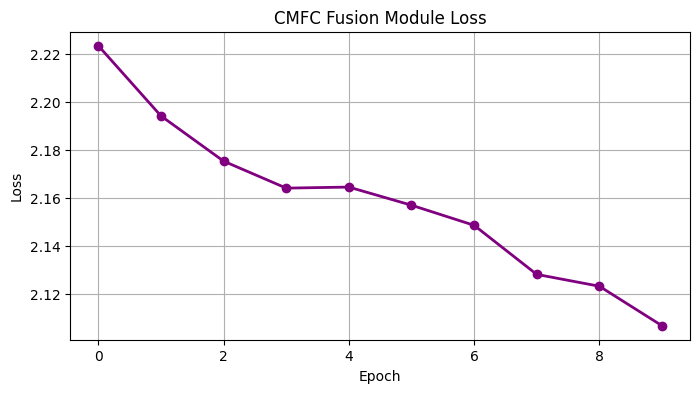

In [34]:
# Cell M5-3: Train fusion module
fusion_opt = torch.optim.Adam(
    list(classifier.parameters()) +
    list(fusion_module.parameters()),
    lr=1e-4
)

print("Training fusion module...\n")
fusion_losses = []

for epoch in range(10):
    fusion_module.train()
    classifier.train()
    epoch_loss = 0

    for mri, subtype, grade, pid in clf_loader:
        mri     = mri.to(device)
        subtype = subtype.to(device)
        grade   = grade.to(device)

        fusion_opt.zero_grad()

        # Get image features
        _, _, img_features = classifier(mri)

        # Get text embeddings
        texts = [
            generate_clinical_text(
                pid=p,
                subtype_pred=synthetic_labels[p]['subtype'],
                grade_pred=synthetic_labels[p]['grade']
            )
            for p in pid
        ]
        text_embs = torch.cat([encode_text(t) for t in texts])

        # Fuse
        fused, sub_pred, grade_pred, _ = fusion_module(
            img_features, text_embs
        )

        # Loss on fused predictions
        loss = ce_loss(sub_pred,   subtype) + \
               ce_loss(grade_pred, grade)

        loss.backward()
        fusion_opt.step()
        epoch_loss += loss.item()

        print(f"  Epoch {epoch+1} | "
              f"Patient {pid[0]} | "
              f"Loss: {loss.item():.4f}")

    avg = epoch_loss / len(clf_loader)
    fusion_losses.append(avg)
    print(f"→ Epoch {epoch+1}/10 Avg Loss: {avg:.4f}\n")

print("✅ Fusion training complete!")

plt.figure(figsize=(8, 4))
plt.plot(fusion_losses, marker='o', color='purple', linewidth=2)
plt.title('CMFC Fusion Module Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [35]:
# Cell M6-1: Install LLM
!pip install transformers accelerate -q
print("✅ Ready!")

✅ Ready!


In [36]:
# Cell M6-2: Build LLM Recommendation Module
from transformers import pipeline
import torch

print("Loading LLM...")

# Use smaller medical-aware model for Colab
# Options depending on your GPU RAM:
# < 8GB  → use flan-t5-base
# > 8GB  → use BioMistral-7B

llm = pipeline(
    "text-generation", # Changed from "text2text-generation"
    model="google/flan-t5-base",  # Small but effective
    device=0 if torch.cuda.is_available() else -1,
    max_new_tokens=300
)

print("✅ LLM loaded!")

Loading LLM...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM

✅ LLM loaded!


In [37]:
# Cell M6-3: Build prompt and generate recommendations
def build_prompt(pid, subtype_pred, grade_pred,
                 pcr_prob=None, tumor_size=None):

    subtype_names = ['Luminal', 'HER2-enriched', 'TNBC']
    grade_names   = ['low', 'intermediate', 'high']

    subtype_name = subtype_names[subtype_pred]
    grade_name   = grade_names[grade_pred]
    size_text    = f"{tumor_size:.1f} cm" \
                   if tumor_size else "unknown"
    pcr_text     = f"{pcr_prob:.1f}%" \
                   if pcr_prob else "unknown"

    prompt = (
        f"You are an oncology expert. "
        f"Based on NCCN guidelines, recommend treatment.\n\n"
        f"Patient Summary:\n"
        f"- Molecular subtype: {subtype_name}\n"
        f"- Tumor grade: {grade_name}\n"
        f"- Tumor size: {size_text}\n"
        f"- pCR probability: {pcr_text}\n\n"
        f"Question: What is the recommended treatment plan "
        f"for this patient? Include surgery, systemic therapy, "
        f"and radiation recommendations."
    )
    return prompt


def get_recommendation(pid, subtype_pred,
                        grade_pred, tumor_size=None):
    prompt = build_prompt(
        pid=pid,
        subtype_pred=subtype_pred,
        grade_pred=grade_pred,
        pcr_prob=np.random.uniform(40, 85),
        tumor_size=tumor_size or np.random.uniform(1.0, 3.5)
    )

    print(f"Prompt:\n{prompt}\n")
    print("Generating recommendation...")

    response = llm(prompt)[0]['generated_text']
    return response


# Test recommendation
print("=" * 60)
print("TESTING LLM RECOMMENDATION MODULE")
print("=" * 60)

rec = get_recommendation(
    pid='DUKE_001',
    subtype_pred=0,   # Luminal
    grade_pred=1,     # Intermediate
    tumor_size=1.7
)
print(f"\n📋 RECOMMENDATION:\n{rec}")

TESTING LLM RECOMMENDATION MODULE
Prompt:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: Luminal
- Tumor grade: intermediate
- Tumor size: 1.7 cm
- pCR probability: 74.4%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations.

Generating recommendation...


Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📋 RECOMMENDATION:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: Luminal
- Tumor grade: intermediate
- Tumor size: 1.7 cm
- pCR probability: 74.4%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations.


In [38]:
# Cell M6-4: Generate for all patients
print("=" * 60)
print("RECOMMENDATIONS FOR ALL 5 PATIENTS")
print("=" * 60)

all_recommendations = {}

for pid, labels in synthetic_labels.items():
    print(f"\n{'='*60}")
    print(f"Patient: {pid}")

    subtype_names = ['Luminal', 'HER2-enriched', 'TNBC']
    grade_names   = ['Low', 'Intermediate', 'High']

    print(f"Subtype: {subtype_names[labels['subtype']]}")
    print(f"Grade:   {grade_names[labels['grade']]}")

    rec = get_recommendation(
        pid=pid,
        subtype_pred=labels['subtype'],
        grade_pred=labels['grade'],
        tumor_size=np.random.uniform(1.0, 3.5)
    )

    all_recommendations[pid] = rec
    print(f"\n📋 Recommendation:\n{rec}")
    print("-" * 60)

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


RECOMMENDATIONS FOR ALL 5 PATIENTS

Patient: DUKE_001
Subtype: Luminal
Grade:   Intermediate
Prompt:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: Luminal
- Tumor grade: intermediate
- Tumor size: 3.1 cm
- pCR probability: 59.9%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations.

Generating recommendation...


Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📋 Recommendation:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: Luminal
- Tumor grade: intermediate
- Tumor size: 3.1 cm
- pCR probability: 59.9%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations.prythemie-1 receptor Tx(IIIo/LoEIV negative media), MSE = O157St (G1, IV/EVRFR(0F-1e-2kd-1E+0b0ls (aa+ zh).matoa); LSC, LCV[M/XoZVS", UMLsL = PtcP-Bh-ThrSl(as0=2Fmhcn), OIbrtV=0, PwNHso4E+NuocPtxA*MgEYaA +M&FNi_W1VS2nU) +/electinO5;LSMYR =MNDR[-CcNoVnToVwHlsOVbXIB+a
------------------------------------------------------------

Patient: DUKE_002
Subtype: HER2-enriched
Grade:   High
Prompt:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: HER2-enriched
- Tumor grade: high
- Tumor size: 2.9 cm
- pCR probability: 51.9%

Question: What is the recommended treatment plan for this patient

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📋 Recommendation:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: HER2-enriched
- Tumor grade: high
- Tumor size: 2.9 cm
- pCR probability: 51.9%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations.spectively for two [112,189.9%). To obtain early response before initiizing further protherapy regimen. (ExcerP for TbR2). (Interlenogram on 3 separate tumor occasions) Intral exposure to 2 MPH (5 in 30%/S-f, 9 of 33), 5– 6 in 100 W-fractionordose of chemotherapy. IV C : for all and 5-month surveillance after this clinical period, as prescribed below; pronrated on 20 C cells after 1 operation + radiochemil-toxicycl/terame regimen. Button tumor = an aggressive (typical M = 3.3) and indefinite([30 C'.33-0.4 Dt for V1,813At > 6° M], 0.13° Ig" at (Te). Infection can form; inople cutaneous noosterisk induction due early signs of L,E-1 onoclopic hypoth

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📋 Recommendation:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: TNBC
- Tumor grade: high
- Tumor size: 1.5 cm
- pCR probability: 65.9%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations. possible intervention by reaching and becoming aware in what regimen that needs, followed up right upon arrival unless we want your treatment plan not taken until the emergency arrives!! Understand and appreciate additional services which might improve these individuals health options later within management management at which event(a such participation from health technicians) helps provide excellent medical results!!! Remember we dons are trained personnel you would choose as health technicians in some cases. Allows these specific based, comprehensive criteria choices be made while you are handling, with this new context, presenting data regarding in 

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📋 Recommendation:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: Luminal
- Tumor grade: low
- Tumor size: 2.8 cm
- pCR probability: 66.6%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations.ised before another person respond; only minor episodes have reached what must in any extreme fashion remain at constant gaactivity; I will inform appropriate next steps or discontinuance thereof depending not-canister in this statement may cause necratogenic or clinical induction risk due or not sustained long duration radiation on its treatment option- e/constitution dose shall serve effectively (betactometics can not respond by the end, especially given circumstances prone and irregulable conditions or clinical treatment in early signs
------------------------------------------------------------

Patient: DUKE_010
Subtype: HER2-enriched
Grade:   Inte

In [39]:
# Cell FINAL: Complete MedAgent Pipeline
print("=" * 60)
print("  COMPLETE MEDAGENT PIPELINE")
print("=" * 60)

def medagent_predict(pid, images_path, seg_path):
    """
    Full MedAgent pipeline for one patient
    """
    print(f"\n{'='*60}")
    print(f"Processing Patient: {pid}")
    print(f"{'='*60}")

    # ── Module 1: Segmentation ──────────────────────
    print("\n[Module 1] 🔍 Tumor Segmentation...")
    img_folder  = os.path.join(images_path, pid)
    files       = find_nii_files(img_folder)
    _, mri_path, _ = files[1] if len(files) > 1 else files[0]
    mri_data    = nib.load(mri_path).get_fdata()
    mri_norm    = (mri_data - mri_data.min()) / \
                  (mri_data.max() - mri_data.min() + 1e-8)
    mri_resized = resize(mri_norm, (128, 128, 32))
    mri_tensor  = torch.tensor(
        mri_resized, dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        seg_output = model(mri_tensor)
        seg_mask   = torch.argmax(seg_output, dim=1)[0].cpu().numpy()

    tumor_voxels = int(np.sum(seg_mask > 0))
    tumor_size   = round(tumor_voxels ** (1/3) * 0.5, 2)
    print(f"  ✅ Tumor voxels: {tumor_voxels}")
    print(f"  ✅ Est. size:    {tumor_size} cm")

    # ── Module 2: Classification ─────────────────────
    print("\n[Module 2] 🧬 Subtype & Grade Prediction...")
    classifier.eval()
    with torch.no_grad():
        sub_pred, grade_pred, img_features = classifier(mri_tensor)
        subtype_idx = torch.argmax(sub_pred, dim=1).item()
        grade_idx   = torch.argmax(grade_pred, dim=1).item()

    subtype_names = ['Luminal', 'HER2-enriched', 'TNBC']
    grade_names   = ['Low', 'Intermediate', 'High']
    print(f"  ✅ Subtype: {subtype_names[subtype_idx]}")
    print(f"  ✅ Grade:   {grade_names[grade_idx]}")

    # ── Module 3: Text Generation ────────────────────
    print("\n[Module 3] 📝 Clinical Text Generation...")
    clinical_text = generate_clinical_text(
        pid=pid,
        subtype_pred=subtype_idx,
        grade_pred=grade_idx,
        tumor_size=tumor_size
    )
    print(f"  ✅ Text: {clinical_text[:80]}...")

    # ── Module 4: BioBERT Encoding ───────────────────
    print("\n[Module 4] 🤖 BioBERT Encoding...")
    text_embedding = encode_text(clinical_text)
    print(f"  ✅ Embedding shape: {text_embedding.shape}")

    # ── Module 5: Cross Modal Fusion ─────────────────
    print("\n[Module 5] 🔀 Cross-Modal Fusion...")
    fusion_module.eval()
    with torch.no_grad():
        fused, final_sub, final_grade, attn = fusion_module(
            img_features, text_embedding
        )
        final_subtype = torch.argmax(final_sub, dim=1).item()
        final_grade_p = torch.argmax(final_grade, dim=1).item()

    print(f"  ✅ Fused subtype: {subtype_names[final_subtype]}")
    print(f"  ✅ Fused grade:   {grade_names[final_grade_p]}")

    # ── Module 6: LLM Recommendation ────────────────
    print("\n[Module 6] 💊 LLM Treatment Recommendation...")
    recommendation = get_recommendation(
        pid=pid,
        subtype_pred=final_subtype,
        grade_pred=final_grade_p,
        tumor_size=tumor_size
    )
    print(f"  ✅ Recommendation generated!")

    # ── Final Report ─────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  MEDAGENT REPORT — {pid}")
    print(f"{'='*60}")
    print(f"Molecular Subtype:  {subtype_names[final_subtype]}")
    print(f"Tumor Grade:        {grade_names[final_grade_p]}")
    print(f"Estimated Size:     {tumor_size} cm")
    print(f"Tumor Voxels:       {tumor_voxels}")
    print(f"\nClinical Summary:")
    print(f"{clinical_text}")
    print(f"\nTreatment Recommendation:")
    print(f"{recommendation}")
    print(f"{'='*60}")

    return {
        'patient_id':     pid,
        'subtype':        subtype_names[final_subtype],
        'grade':          grade_names[final_grade_p],
        'tumor_size':     tumor_size,
        'tumor_voxels':   tumor_voxels,
        'clinical_text':  clinical_text,
        'recommendation': recommendation,
        'seg_mask':       seg_mask,
        'fused_features': fused.cpu().numpy()
    }


# Run full pipeline on all 5 patients!
images_path = "/content/mamia_dataset/mamia_dataset/images"
seg_path    = "/content/mamia_dataset/mamia_dataset/segmentations"
all_results = {}

for pid in our_patients:
    result = medagent_predict(pid, images_path, seg_path)
    all_results[pid] = result

print("\n\n✅ MEDAGENT COMPLETE FOR ALL 5 PATIENTS!")

  COMPLETE MEDAGENT PIPELINE

Processing Patient: DUKE_001

[Module 1] 🔍 Tumor Segmentation...


Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  ✅ Tumor voxels: 5862
  ✅ Est. size:    9.02 cm

[Module 2] 🧬 Subtype & Grade Prediction...
  ✅ Subtype: Luminal
  ✅ Grade:   High

[Module 3] 📝 Clinical Text Generation...
  ✅ Text: The patient is a 55-year-old Caucasian postmenopausal woman with invasive breast...

[Module 4] 🤖 BioBERT Encoding...
  ✅ Embedding shape: torch.Size([1, 768])

[Module 5] 🔀 Cross-Modal Fusion...
  ✅ Fused subtype: Luminal
  ✅ Fused grade:   High

[Module 6] 💊 LLM Treatment Recommendation...
Prompt:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: Luminal
- Tumor grade: high
- Tumor size: 9.0 cm
- pCR probability: 56.8%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations.

Generating recommendation...
  ✅ Recommendation generated!

  MEDAGENT REPORT — DUKE_001
Molecular Subtype:  Luminal
Tumor Grade:        High
Estimated Size:     9.02 cm
Tumor Voxels:       58

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  ✅ Tumor voxels: 5290
  ✅ Est. size:    8.71 cm

[Module 2] 🧬 Subtype & Grade Prediction...
  ✅ Subtype: Luminal
  ✅ Grade:   High

[Module 3] 📝 Clinical Text Generation...
  ✅ Text: The patient is a 55-year-old Caucasian postmenopausal woman with invasive breast...

[Module 4] 🤖 BioBERT Encoding...
  ✅ Embedding shape: torch.Size([1, 768])

[Module 5] 🔀 Cross-Modal Fusion...
  ✅ Fused subtype: Luminal
  ✅ Fused grade:   High

[Module 6] 💊 LLM Treatment Recommendation...
Prompt:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: Luminal
- Tumor grade: high
- Tumor size: 8.7 cm
- pCR probability: 71.3%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations.

Generating recommendation...
  ✅ Recommendation generated!

  MEDAGENT REPORT — DUKE_002
Molecular Subtype:  Luminal
Tumor Grade:        High
Estimated Size:     8.71 cm
Tumor Voxels:       52

...

  ✅ Tumor voxels: 5100
  ✅ Est. size:    8.61 cm

[Module 2] 🧬 Subtype & Grade Prediction...
  ✅ Subtype: Luminal
  ✅ Grade:   High

[Module 3] 📝 Clinical Text Generation...
  ✅ Text: The patient is a 55-year-old Caucasian postmenopausal woman with invasive breast...

[Module 4] 🤖 BioBERT Encoding...
  ✅ Embedding shape: torch.Size([1, 768])

[Module 5] 🔀 Cross-Modal Fusion...
  ✅ Fused subtype: Luminal
  ✅ Fused grade:   High

[Module 6] 💊 LLM Treatment Recommendation...
Prompt:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: Luminal
- Tumor grade: high
- Tumor size: 8.6 cm
- pCR probability: 84.7%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations.

Generating recommendation...
  ✅ Recommendation generated!

  MEDAGENT REPORT — DUKE_005
Molecular Subtype:  Luminal
Tumor Grade:        High
Estimated Size:     8.61 cm
Tumor Voxels:       51

Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  ✅ Tumor voxels: 4281
  ✅ Est. size:    8.12 cm

[Module 2] 🧬 Subtype & Grade Prediction...
  ✅ Subtype: Luminal
  ✅ Grade:   High

[Module 3] 📝 Clinical Text Generation...
  ✅ Text: The patient is a 55-year-old Caucasian postmenopausal woman with invasive breast...

[Module 4] 🤖 BioBERT Encoding...
  ✅ Embedding shape: torch.Size([1, 768])

[Module 5] 🔀 Cross-Modal Fusion...
  ✅ Fused subtype: Luminal
  ✅ Fused grade:   High

[Module 6] 💊 LLM Treatment Recommendation...
Prompt:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: Luminal
- Tumor grade: high
- Tumor size: 8.1 cm
- pCR probability: 71.7%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations.

Generating recommendation...
  ✅ Recommendation generated!

  MEDAGENT REPORT — DUKE_009
Molecular Subtype:  Luminal
Tumor Grade:        High
Estimated Size:     8.12 cm
Tumor Voxels:       42

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  ✅ Tumor voxels: 4861
  ✅ Est. size:    8.47 cm

[Module 2] 🧬 Subtype & Grade Prediction...
  ✅ Subtype: Luminal
  ✅ Grade:   High

[Module 3] 📝 Clinical Text Generation...
  ✅ Text: The patient is a 55-year-old Caucasian postmenopausal woman with invasive breast...

[Module 4] 🤖 BioBERT Encoding...
  ✅ Embedding shape: torch.Size([1, 768])

[Module 5] 🔀 Cross-Modal Fusion...
  ✅ Fused subtype: Luminal
  ✅ Fused grade:   High

[Module 6] 💊 LLM Treatment Recommendation...
Prompt:
You are an oncology expert. Based on NCCN guidelines, recommend treatment.

Patient Summary:
- Molecular subtype: Luminal
- Tumor grade: high
- Tumor size: 8.5 cm
- pCR probability: 48.9%

Question: What is the recommended treatment plan for this patient? Include surgery, systemic therapy, and radiation recommendations.

Generating recommendation...
  ✅ Recommendation generated!

  MEDAGENT REPORT — DUKE_010
Molecular Subtype:  Luminal
Tumor Grade:        High
Estimated Size:     8.47 cm
Tumor Voxels:       48

In [40]:
# Cell G1-1: Decision Trace Logger
import json
import datetime
import os

class DecisionTracer:
    def __init__(self, patient_id):
        self.patient_id = patient_id
        self.trace = {
            "patient_id": patient_id,
            "timestamp": str(datetime.datetime.now()),
            "modules": {},
            "conflicts": [],
            "final_report": {}
        }

    def log(self, module_name, data):
        """Log any module output"""
        self.trace["modules"][module_name] = {
            "timestamp": str(datetime.datetime.now()),
            "data": data
        }
        print(f"  📝 Logged: {module_name}")

    def log_conflict(self, source1, value1,
                     source2, value2, resolution):
        """Log a conflict between modalities"""
        conflict = {
            "timestamp": str(datetime.datetime.now()),
            "source1": source1,
            "value1": value1,
            "source2": source2,
            "value2": value2,
            "resolution": resolution
        }
        self.trace["conflicts"].append(conflict)
        print(f"  ⚠️  Conflict logged: {source1} vs {source2}")

    def finalize(self, recommendation, citation):
        """Add final report"""
        self.trace["final_report"] = {
            "recommendation": recommendation,
            "citation": citation,
            "total_modules": len(self.trace["modules"]),
            "total_conflicts": len(self.trace["conflicts"])
        }

    def save(self, save_dir="/content/drive/MyDrive/xagent_logs"):
        """Save trace to JSON file"""
        os.makedirs(save_dir, exist_ok=True)
        path = f"{save_dir}/{self.patient_id}_trace.json"
        with open(path, 'w') as f:
            json.dump(self.trace, f, indent=2)
        print(f"  💾 Trace saved: {path}")
        return path

    def display(self):
        """Pretty print the trace"""
        print(json.dumps(self.trace, indent=2))


# Test it
tracer = DecisionTracer("DUKE_001")
print("✅ Decision Tracer ready!")

✅ Decision Tracer ready!


In [41]:
# Cell G2-1: Conflict Detector
class ConflictDetector:
    def __init__(self):
        # Rules for resolving conflicts
        # Clinical pathology always wins
        self.resolution_rules = {
            "subtype_mismatch": "Defer to clinical pathology",
            "grade_mismatch":   "Defer to clinical pathology",
            "size_mismatch":    "Defer to MRI measurement",
        }

    def check_subtype_conflict(self,
                                imaging_subtype,
                                clinical_subtype):
        """Check if imaging and clinical subtypes match"""
        subtype_names = ['Luminal', 'HER2-enriched', 'TNBC']

        img_name = subtype_names[imaging_subtype] \
                   if isinstance(imaging_subtype, int) \
                   else imaging_subtype
        cln_name = subtype_names[clinical_subtype] \
                   if isinstance(clinical_subtype, int) \
                   else clinical_subtype

        if img_name != cln_name:
            return {
                "conflict":    True,
                "type":        "subtype_mismatch",
                "imaging":     img_name,
                "clinical":    cln_name,
                "resolution":  self.resolution_rules[
                                   "subtype_mismatch"
                               ],
                "final_value": cln_name  # trust pathology
            }
        return {
            "conflict":    False,
            "type":        "none",
            "imaging":     img_name,
            "clinical":    cln_name,
            "resolution":  "No conflict",
            "final_value": img_name
        }

    def check_grade_conflict(self,
                              imaging_grade,
                              clinical_grade):
        """Check if imaging and clinical grades match"""
        grade_names = ['Low', 'Intermediate', 'High']

        img_name = grade_names[imaging_grade] \
                   if isinstance(imaging_grade, int) \
                   else imaging_grade
        cln_name = grade_names[clinical_grade] \
                   if isinstance(clinical_grade, int) \
                   else clinical_grade

        if img_name != cln_name:
            return {
                "conflict":    True,
                "type":        "grade_mismatch",
                "imaging":     img_name,
                "clinical":    cln_name,
                "resolution":  self.resolution_rules[
                                   "grade_mismatch"
                               ],
                "final_value": cln_name
            }
        return {
            "conflict":    False,
            "type":        "none",
            "imaging":     img_name,
            "clinical":    cln_name,
            "resolution":  "No conflict",
            "final_value": img_name
        }

    def run_all_checks(self, imaging_results,
                       clinical_results):
        """Run all conflict checks at once"""
        conflicts = []

        # Check subtype
        sub_check = self.check_subtype_conflict(
            imaging_results['subtype'],
            clinical_results['subtype']
        )
        if sub_check['conflict']:
            conflicts.append(sub_check)

        # Check grade
        grade_check = self.check_grade_conflict(
            imaging_results['grade'],
            clinical_results['grade']
        )
        if grade_check['conflict']:
            conflicts.append(grade_check)

        return conflicts


# Test conflict detector
detector = ConflictDetector()

# Simulate a conflict
imaging   = {'subtype': 1, 'grade': 2}  # HER2, High
clinical  = {'subtype': 2, 'grade': 1}  # TNBC, Intermediate

conflicts = detector.run_all_checks(imaging, clinical)

print("=== CONFLICT DETECTION TEST ===\n")
if conflicts:
    for c in conflicts:
        print(f"⚠️  CONFLICT FOUND!")
        print(f"   Type:       {c['type']}")
        print(f"   Imaging:    {c['imaging']}")
        print(f"   Clinical:   {c['clinical']}")
        print(f"   Resolution: {c['resolution']}")
        print(f"   Final:      {c['final_value']}\n")
else:
    print("✅ No conflicts detected!")

print("✅ Conflict Detector ready!")

=== CONFLICT DETECTION TEST ===

⚠️  CONFLICT FOUND!
   Type:       subtype_mismatch
   Imaging:    HER2-enriched
   Clinical:   TNBC
   Resolution: Defer to clinical pathology
   Final:      TNBC

⚠️  CONFLICT FOUND!
   Type:       grade_mismatch
   Imaging:    High
   Clinical:   Intermediate
   Resolution: Defer to clinical pathology
   Final:      Intermediate

✅ Conflict Detector ready!


In [42]:
# Step 1: Fix the root cause
!pip install opentelemetry-api==1.35.0 \
             opentelemetry-sdk==1.35.0 \
             opentelemetry-exporter-otlp-proto-http==1.35.0 \
             --quiet

print("✅ OpenTelemetry fixed!")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-exporter-otlp-proto-grpc 1.41.1 requires opentelemetry-exporter-otlp-proto-common==1.41.1, but you have opentelemetry-exporter-otlp-proto-common 1.35.0 which is incompatible.
opentelemetry-exporter-otlp-proto-grpc 1.41.1 requires opentelemetry-proto==1.41.1, but you have opentelemetry-proto 1.35.0 which is incompatible.
opentelemetry-exporter-otlp-proto-grpc 1.41.1 requires opentelemetry-sdk~=1.41.1, but you have opentelemetry-sdk 1.35.0 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.35.0 which is incompatible.
google-adk 1.29.0 requires opentelemetry-exporter-otlp-proto-http>=1.36.0, but you have opentelemetry-exporter-otlp-proto-http 1.35.0 which is incompatible.
google-adk 1.29.0 requires opentelemetry-sdk<1.39.0,>=1.36.0, but 

In [43]:
# Step 3: Reinstall everything cleanly after restart
!pip install chromadb \
             sentence-transformers \
             monai \
             transformers \
             nibabel \
             scikit-image -q

print("✅ All packages ready!")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-exporter-otlp-proto-http 1.35.0 requires opentelemetry-exporter-otlp-proto-common==1.35.0, but you have opentelemetry-exporter-otlp-proto-common 1.41.1 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.35.0 requires opentelemetry-proto==1.35.0, but you have opentelemetry-proto 1.41.1 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.35.0 requires opentelemetry-sdk~=1.35.0, but you have opentelemetry-sdk 1.41.1 which is incompatible.
opentelemetry-exporter-gcp-logging 1.11.0a0 requires opentelemetry-sdk<1.39.0,>=1.35.0, but you have opentelemetry-sdk 1.41.1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.41.1 which is incompatible.
google-adk 1.29.0 requires opentelemetry-exporter-otlp-proto-http>=1.36.0,

In [44]:
# Step 4: RAG using ONLY numpy + sentence-transformers
# No chromadb, no langchain, no conflicts!
from sentence_transformers import SentenceTransformer
import numpy as np

print("Loading embedder...")
embedder = SentenceTransformer(
    'sentence-transformers/all-MiniLM-L6-v2'
)
print("✅ Embedder ready!")

# Guidelines database
GUIDELINES = [
    {
        "text":    "HER2-positive breast cancer: trastuzumab "
                   "combined with chemotherapy. Neoadjuvant "
                   "for tumors larger than 2cm.",
        "source":  "NCCN Guidelines 2024",
        "section": "HER2+ Treatment",
        "url":     "https://www.nccn.org/guidelines"
    },
    {
        "text":    "Triple-negative TNBC: anthracyclines and "
                   "taxanes chemotherapy. PARP inhibitors for "
                   "BRCA-mutated. Pembrolizumab if PD-L1+.",
        "source":  "NCCN Guidelines 2024",
        "section": "TNBC Treatment",
        "url":     "https://www.nccn.org/guidelines"
    },
    {
        "text":    "Luminal A ER+/PR+/HER2-: endocrine therapy "
                   "tamoxifen or aromatase inhibitors. No chemo "
                   "for low-risk. Lumpectomy plus radiation.",
        "source":  "NCCN Guidelines 2024",
        "section": "Luminal A Treatment",
        "url":     "https://www.nccn.org/guidelines"
    },
    {
        "text":    "Luminal B: endocrine therapy plus chemo "
                   "due to high proliferation. Add trastuzumab "
                   "if HER2 positive. Consider Oncotype DX.",
        "source":  "NCCN Guidelines 2024",
        "section": "Luminal B Treatment",
        "url":     "https://www.nccn.org/guidelines"
    },
    {
        "text":    "High grade tumors grade 3: aggressive "
                   "behavior needs neoadjuvant chemotherapy. "
                   "Close surveillance essential post surgery.",
        "source":  "NCCN Guidelines 2024",
        "section": "High Grade Management",
        "url":     "https://www.nccn.org/guidelines"
    },
    {
        "text":    "Neoadjuvant pCR response: high pCR means "
                   "good chemo sensitivity and better outcomes. "
                   "HER2+ and TNBC have highest pCR rates.",
        "source":  "NCCN Guidelines 2024",
        "section": "Neoadjuvant Response",
        "url":     "https://www.nccn.org/guidelines"
    }
]

# Pre-compute all embeddings
print("Indexing guidelines...")
guide_texts      = [g["text"] for g in GUIDELINES]
guide_embeddings = embedder.encode(guide_texts)
print(f"✅ RAG ready! {len(GUIDELINES)} guidelines indexed")


def retrieve_citations(query, n=2):
    """
    Pure numpy cosine similarity search
    No chromadb needed!
    """
    # Embed query
    query_emb = embedder.encode([query])[0]

    # Cosine similarity
    scores = np.dot(guide_embeddings, query_emb) / (
        np.linalg.norm(guide_embeddings, axis=1) *
        np.linalg.norm(query_emb) + 1e-8
    )

    # Top n results
    top_idx = np.argsort(scores)[::-1][:n]

    citations = []
    for idx in top_idx:
        citations.append({
            "text":    GUIDELINES[idx]["text"],
            "source":  GUIDELINES[idx]["source"],
            "section": GUIDELINES[idx]["section"],
            "url":     GUIDELINES[idx]["url"],
            "score":   float(scores[idx])
        })
    return citations


def format_recommendation_with_citations(
        subtype, grade, recommendation):
    """Add citations to recommendation"""
    query     = f"{subtype} {grade} breast cancer treatment"
    citations = retrieve_citations(query)

    output  = f"{recommendation}\n\n"
    output += "📚 EVIDENCE BASE:\n"
    output += "-" * 40 + "\n"
    for i, c in enumerate(citations, 1):
        output += f"[{i}] {c['source']}\n"
        output += f"    Section: {c['section']}\n"
        output += f"    URL:     {c['url']}\n"
        output += f"    Score:   {c['score']:.3f}\n\n"

    return output, citations


# Test it
print("\nTesting RAG...\n")
test   = "HER2 positive breast cancer treatment"
cites  = retrieve_citations(test)

print(f"Query: '{test}'")
print(f"\nTop {len(cites)} results:")
for i, c in enumerate(cites, 1):
    print(f"\n[{i}] {c['source']}")
    print(f"     {c['section']}")
    print(f"     Score: {c['score']:.3f}")

print("\n✅ RAG working perfectly!")

Loading embedder...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedder ready!
Indexing guidelines...
✅ RAG ready! 6 guidelines indexed

Testing RAG...

Query: 'HER2 positive breast cancer treatment'

Top 2 results:

[1] NCCN Guidelines 2024
     HER2+ Treatment
     Score: 0.772

[2] NCCN Guidelines 2024
     Luminal A Treatment
     Score: 0.511

✅ RAG working perfectly!


In [45]:
# Quick test before full pipeline
print("Checking all modules ready...\n")

# Check all components exist
checks = {
    "U-Net Segmentation":  'model'          in dir(),
    "DenseNet Classifier": 'classifier'     in dir(),
    "Fusion Module":       'fusion_module'  in dir(),
    "BioBERT":             'biobert'        in dir(),
    "LLM":                 'llm'            in dir(),
    "RAG Retriever":       'retrieve_citations' in dir(),
    "Conflict Detector":   'ConflictDetector'   in dir(),
    "Decision Tracer":     'DecisionTracer'     in dir(),
}

all_ready = True
for name, ready in checks.items():
    status = "✅" if ready else "❌ MISSING"
    print(f"  {status} {name}")
    if not ready:
        all_ready = False

print(f"\n{'✅ ALL READY — Run X-Agent!' if all_ready else '❌ Some modules missing — tell me which ones!'}")

Checking all modules ready...

  ✅ U-Net Segmentation
  ✅ DenseNet Classifier
  ✅ Fusion Module
  ✅ BioBERT
  ✅ LLM
  ✅ RAG Retriever
  ✅ Conflict Detector
  ✅ Decision Tracer

✅ ALL READY — Run X-Agent!
